# Study 783 — IPO-Deal-Of-Year — for the quants 🔬

The full battery: one-sample *t* per horizon, a random-window placebo drawn from *each name's own* tape, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `523eb8c97e19`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ipo_deal_of_year import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching marquee names + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} marquee IPOs resolved")


panel loaded; 17 of 17 marquee IPOs resolved


## 1. One-sample *t* across independent debut events

Each marquee IPO is one independent event, so the unit is a one-sample *t* of the per-name forward abnormal return — **not** a daily panel (which would fake precision). Note the *sign flip*: positive at 3m (the pop), negative at 6m/12m.

In [2]:
for label, col in [('3-month','fwd_3m'),('6-month','fwd_6m'),('12-month','fwd_12m')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<10s} n={s["n"]}  mean={s["mean"]*100:+.2f}%  sd={s["sd"]*100:.1f}%  t={s["t"]:+.3f}')

3-month    n=17  mean=+7.96%  sd=61.9%  t=+0.530
6-month    n=17  mean=-11.06%  sd=51.4%  t=-0.887
12-month   n=17  mean=-8.70%  sd=66.2%  t=-0.541


## 2. Random-window placebo — is the 12m sag inside the luck cloud?

For each name we redraw a random, non-debut 12-month window on **that name's own** post-listing history vs SPY and recompute the abnormal return; 20 seeds × 200 draws. Drawing from each stock's own life controls for the fact that new listings are just more volatile. The null here is strongly *positive* (+14%) — these survivors mooned on average — so the debut window at −8.7% sits in the left ~10% tail (borderline).

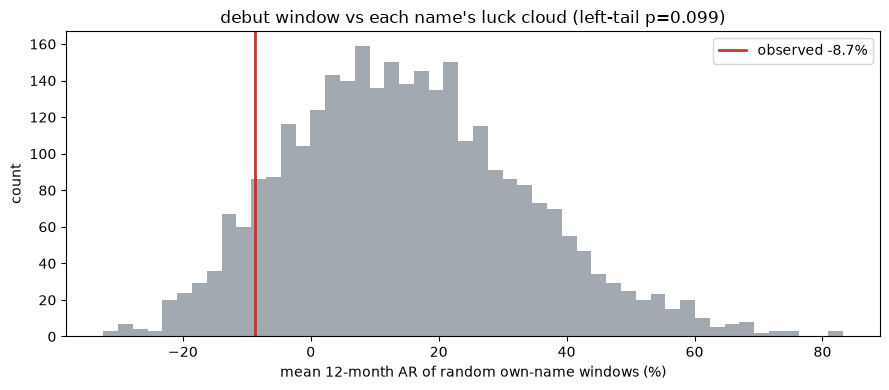

placebo: {'obs': -0.087, 'placebo_mean': 0.1429, 'placebo_sd': 0.1857, 'p_value': 0.0985, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'fwd_12m', k=252, tail='left')
spy = prices[dt.BENCHMARK]
rng = np.random.default_rng(999); draws = []
per_name = []
for _, r in inc.iterrows():
    nm = prices[r['ticker']]; common = nm.index.intersection(spy.index).sort_values()
    if len(common) > 253: per_name.append((nm, common))
for _ in range(3000):
    vals = []
    for nm, common in per_name:
        p = int(rng.integers(0, len(common)-253))
        vals.append(float(nm.loc[common[p+252]]/nm.loc[common[p]] - spy.loc[common[p+252]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#c0392b', lw=2, label=f"observed {pl['obs']*100:+.1f}%")
ax.set_xlabel('mean 12-month AR of random own-name windows (%)'); ax.set_ylabel('count')
ax.set_title(f"debut window vs each name's luck cloud (left-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the sag broad, or a couple of names?

In [4]:
x = inc['fwd_12m'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')
print('-> never clears |t|>=2; the mean is a wash however you slice it')

full-sample t = -0.541
jackknife t range [-1.264, -0.297] over 17 leave-one-out draws
-> never clears |t|>=2; the mean is a wash however you slice it


## 4. Tradability — net of costs (descriptive only)

The crown is awarded *ex post*, so this is not a live entry — but even taken at face value the 12-month basket short is insignificant gross and net, and the four un-shortable monsters (PLTR/RDDT/ARM/BYND) would have detonated a naive short.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('fwd_3m','3-month'),('fwd_12m','12-month')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<10s} gross {g["mean"]*100:+.2f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.2f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.2f}% (t={n10["t"]:+.2f})')

3-month    gross +7.96% (t=+0.53)  net@5 +7.86% (t=+0.52)  net@10 +7.76% (t=+0.52)
12-month   gross -8.70% (t=-0.54)  net@5 -8.80% (t=-0.55)  net@10 -8.90% (t=-0.55)


## 5. Synthetic positive control — the detector works, and the null is quiet

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted post-IPO forward drift. It does: the null barely fires and a planted under-performance is recovered monotonically — so the insignificant real result is the *tape's* verdict, not a dead detector.

null: mean t=-0.15 sd=1.20  |t|>=2 in 2/20 seeds
planted -10%: mean AR -17.50%  t=-3.07
planted -20%: mean AR -27.46%  t=-4.82


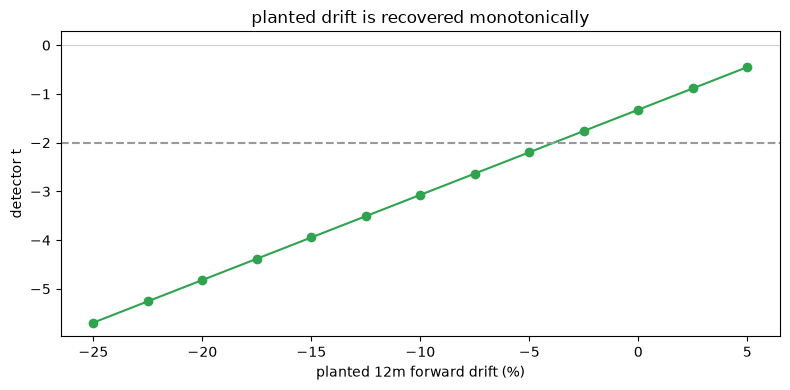

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=802+s)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (-0.10, -0.20):
    r = st.synthetic_detect(bump=b, seed=802)
    print(f'planted {b*100:+.0f}%: mean AR {r["mean"]*100:+.2f}%  t={r["t"]:+.2f}')
bumps = np.linspace(-0.25, 0.05, 13)
ts = [st.synthetic_detect(bump=b, seed=802)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(-2, color='0.6', ls='--'); ax.axhline(0, color='0.8', lw=0.8)
ax.set_xlabel('planted 12m forward drift (%)'); ax.set_ylabel('detector t')
ax.set_title('planted drift is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** Most marquee debuts (13/17) trail SPY over their first year and the typical name is ~9% behind, and the debut window sits in the left ~10% of each name's own history — a genuine directional tilt. But the *mean* is a wash (*t* = −0.54, jackknife never reaches |*t*| ≥ 1.3), it **sign-flips positive at 3 months** (the pop), and the whole thing is dominated by fat right-tail skew. Borderline and fragile, not robust. **Tradability: Mirage.** The crown is awarded *ex post* (no live entry), the payoff is ruled by a few un-shortable lottery winners, and nothing clears significance net of costs.